In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install tensorflow
!pip install keras
!pip install opencv-python

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model

In [ ]:
train_path = "/content/drive/MyDrive/Sepsisproject/dataset/train"
test_path = "/content/drive/MyDrive/Sepsisproject/dataset/test"

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
   target_size = (256,256),
    batch_size=16,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size = (256,256),
    batch_size=16,
    class_mode='binary',
    shuffle=False

)

Found 2076 images belonging to 2 classes.
Found 108 images belonging to 2 classes.


In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(256,256,3)
)


In [ ]:
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

In [ ]:

x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.5159045725646123), 1: np.float64(16.21875)}


In [ ]:
for layer in base_model.layers[-20:]:
    layer.trainable = True
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [ ]:
history_finetune = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
    class_weight=class_weights
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 134s 477ms/step - accuracy: 0.9669 - loss: 1.4956 - val_accuracy: 0.5185 - val_loss: 1.0673
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 30s 228ms/step - accuracy: 1.0000 - loss: 2.6483e-04 - val_accuracy: 0.5185 - val_loss: 0.8613
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 29s 219ms/step - accuracy: 1.0000 - loss: 2.0685e-04 - val_accuracy: 0.4167 - val_loss: 1.3664
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 29s 219ms/step - accuracy: 1.0000 - loss: 9.4514e-05 - val_accuracy: 0.5093 - val_loss: 1.1728
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 29s 222ms/step - accuracy: 1.0000 - loss: 2.7887e-05 - val_accuracy: 0.5370 - val_loss: 0.9180
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 29s 220ms/step - accuracy: 1.0000 - loss: 1.2134e-04 - val_accuracy: 0.7407 - val_loss: 0.4447
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 29s 219ms/step - accuracy: 1.0000 - loss: 2.1567e-05 - val_accuracy: 0.9815 - val_loss: 0.0451
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 29s 221ms/step - a

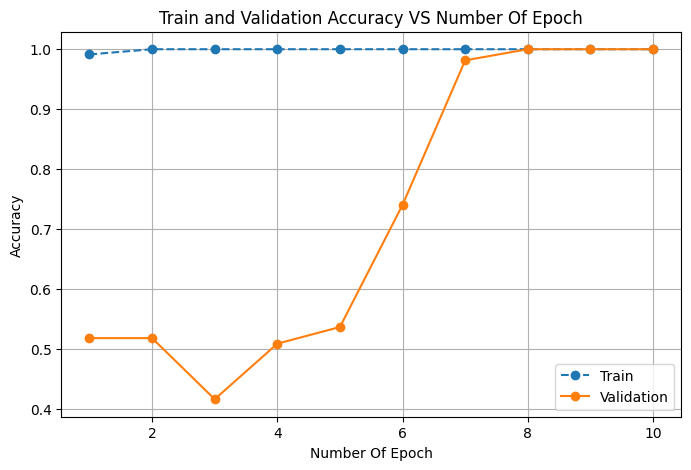

In [ ]:
import matplotlib.pyplot as plt

train_acc = history_finetune.history['accuracy']
val_acc = history_finetune.history['val_accuracy']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, marker='o', linestyle='--', label='Train')
plt.plot(epochs, val_acc, marker='o', label='Validation')

plt.title('Train and Validation Accuracy VS Number Of Epoch')
plt.xlabel('Number Of Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)
plt.show()

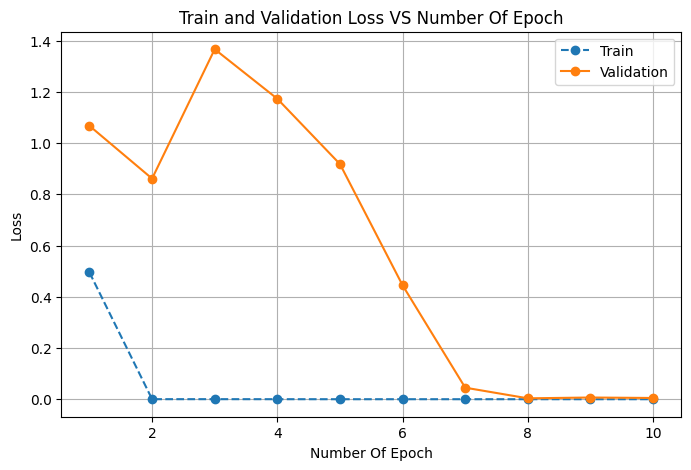

In [ ]:
train_loss = history_finetune.history['loss']
val_loss = history_finetune.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, marker='o', linestyle='--', label='Train')
plt.plot(epochs, val_loss, marker='o', label='Validation')

plt.title('Train and Validation Loss VS Number Of Epoch')
plt.xlabel('Number Of Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
[[3.5674657e-06]]
Infection Detected


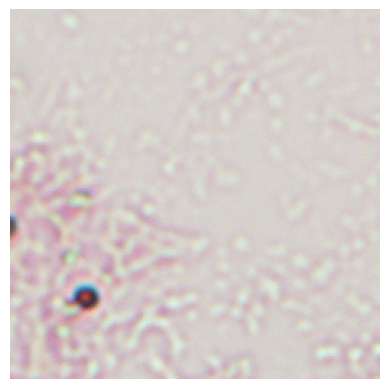

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img = image.load_img("000010_5_5.jpg", target_size=(256,256))
plt.imshow(img)
plt.axis('off')

img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = img/255

prediction = model.predict(img)

print(prediction)

if prediction[0][0] < 0.5:
    print("Infection Detected")
else:
    print("No Infection")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
[[0.999652]]
No Infection


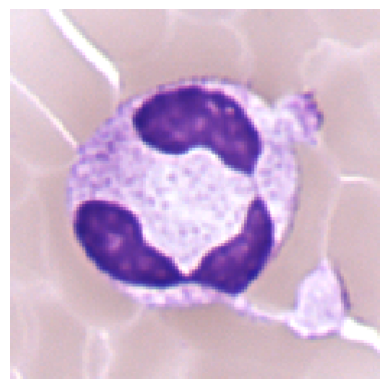

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img("image_100.tif", target_size=(256,256))
plt.imshow(img)
plt.axis('off')

img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = img/255

prediction = model.predict(img)

print(prediction)

if prediction[0][0] < 0.5:
    print("Infection Detected")
else:
    print("No Infection")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[1.4168087e-07]]
Infection Detected


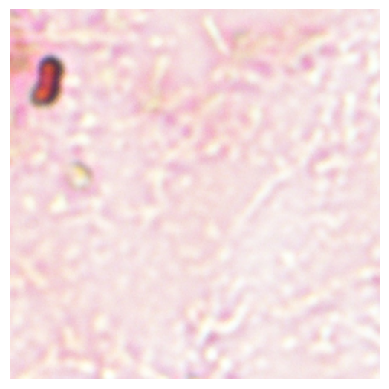

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img = image.load_img("000007_3_6.jpg", target_size=(256,256))
plt.imshow(img)
plt.axis('off')

img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = img/255

prediction = model.predict(img)

print(prediction)

if prediction[0][0] < 0.5:
    print("Infection Detected")
else:
    print("No Infection")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[0.99802375]]
No Infection


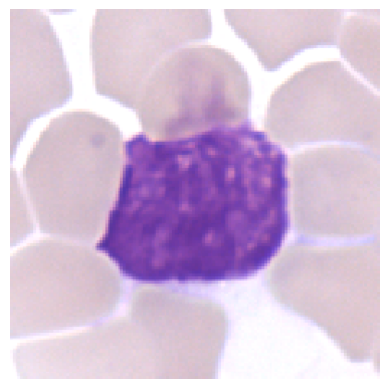

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img = image.load_img("image_109.tif", target_size=(256,256))
plt.imshow(img)
plt.axis('off')

img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = img/255

prediction = model.predict(img)

print(prediction)

if prediction[0][0] < 0.5:
    print("Infection Detected")
else:
    print("No Infection")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[2.6654386e-06]]
Infection Detected


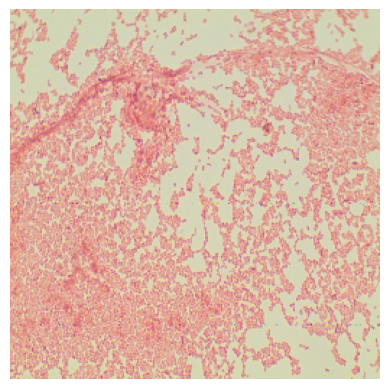

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img = image.load_img("Acinetobacter.baumanii_0004.tif", target_size=(256,256))
plt.imshow(img)
plt.axis('off')

img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = img/255

prediction = model.predict(img)

print(prediction)

if prediction[0][0] < 0.5:
    print("Infection Detected")
else:
    print("No Infection")

In [ ]:
print(train_data.samples)

2076


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
Y_pred = model.predict(test_data)
y_pred = (Y_pred > 0.5)

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 936ms/step


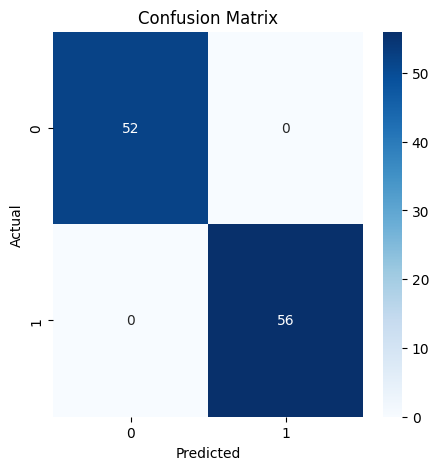

In [ ]:
cm = confusion_matrix(test_data.classes, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
print(classification_report(test_data.classes, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        56

    accuracy                           1.00       108
   macro avg       1.00      1.00      1.00       108
weighted avg       1.00      1.00      1.00       108



In [ ]:
model.save('/content/mydrive/MyDrive/sepsis_bacteria_model.h5')

In [ ]:
from sklearn.metrics import classification_report

Y_pred = model.predict(test_data)
y_pred = (Y_pred > 0.5)

report = classification_report(test_data.classes, y_pred, output_dict=True)

In [ ]:
from sklearn.metrics import classification_report

Y_pred = model.predict(test_data)
y_pred = (Y_pred > 0.5)

report = classification_report(test_data.classes, y_pred, output_dict=True)

precision = report['1']['precision']
recall = report['1']['recall']
f1 = report['1']['f1-score']
accuracy = report['accuracy']

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step


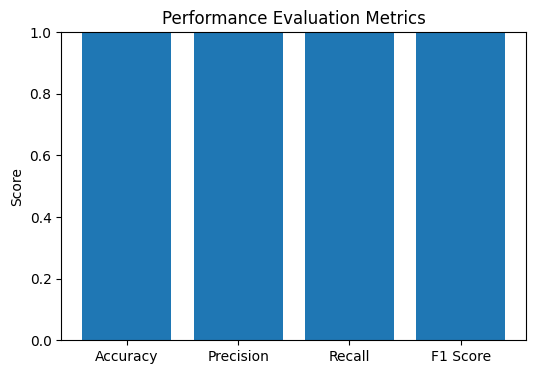

In [ ]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title('Performance Evaluation Metrics')
plt.ylim(0,1)
plt.ylabel('Score')
plt.show()